## Control 2 - Técnicas Computacionales para Radio Interferometría Astronómica

Autores: Juan Pablo Cárdenas - Vicente Mieres

4 de Diciembre de 2025

## Imports

In [1]:
import numpy as np
import cupy as cp
import time
import dask.array as da
from dask.distributed import Client, LocalCluster
import matplotlib.pyplot as plt
from numba import jit, prange
from numba import cuda
import math

c:\Users\juanp\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Pregunta 1

a) Simule un conjunto de visibilidades sintéticas griddeadas en el espacio uv. Las visibilidades griddeadas tienen forma de matriz Nu × Nv × T , donde Nu y Nv son las dimensiones de la grilla uv y T es el número de tiempos de integración. Cree un array de Dask de tamaño 1000 × 1000 × 100 (representando visibilidades griddeadas en una grilla uv de 1000 × 1000 píxeles para 100 tiempos de integración) particionado en bloques de 200 × 200 × 20. Calcule el promedio temporal de las visibilidades usando compute().

In [2]:
def pregunta_1a():
    print("--- Pregunta 1a: Dask Distributed ---")

    cluster = LocalCluster() 
    client = Client(cluster)
    
    print(f"Dashboard disponible en: {client.dashboard_link}")
    
    try:
        # Parámetros
        Nu, Nv = 1000, 1000
        T = 100
        shape = (Nu, Nv, T)       
        chunks = (200, 200, 20)   
        print(f"Creando Dask Array de tamaño {shape} con chunks {chunks}...")

        # Visibilidades
        visibilities = (da.random.standard_normal(shape, chunks=chunks) + 
                        1j * da.random.standard_normal(shape, chunks=chunks))
        
        # Promedio
        mean_operation = visibilities.mean(axis=2)
        
        print("Iniciando cómputo distribuido...")
        start_time = time.time()
        
        temporal_mean = mean_operation.compute()
        
        end_time = time.time()
        
        print(f"Cómputo finalizado en {end_time - start_time:.4f} segundos.")
        print(f"Shape final: {temporal_mean.shape}")
        print(f"Dtype: {temporal_mean.dtype}")

        return temporal_mean

    finally:
        print('Cerrando Clúster')
        client.close()
        cluster.close()

In [3]:
res = pregunta_1a()

--- Pregunta 1a: Dask Distributed ---
Dashboard disponible en: http://127.0.0.1:8787/status
Creando Dask Array de tamaño (1000, 1000, 100) con chunks (200, 200, 20)...
Iniciando cómputo distribuido...
Cómputo finalizado en 5.0592 segundos.
Shape final: (1000, 1000)
Dtype: complex128
Cerrando Clúster


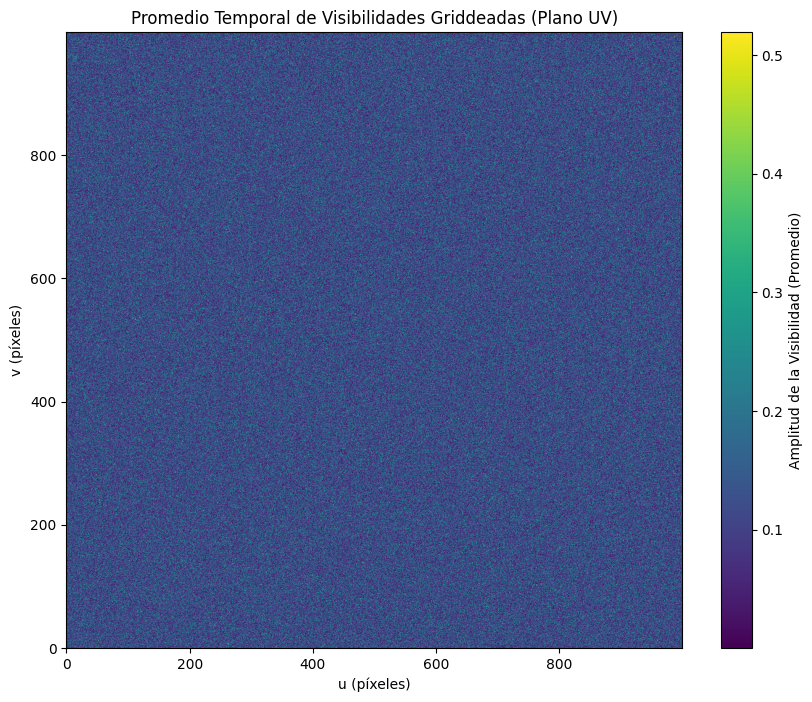

In [4]:
amplitud = np.abs(res)

# 3. Graficar
plt.figure(figsize=(10, 8))
plt.imshow(amplitud, cmap='viridis', origin='lower')
plt.colorbar(label='Amplitud de la Visibilidad (Promedio)')
plt.title('Promedio Temporal de Visibilidades Griddeadas (Plano UV)')
plt.xlabel('u (píxeles)')
plt.ylabel('v (píxeles)')
plt.show()

b) Cree 50 imágenes sintéticas de síntesis de apertura (arrays numpy complejos de tamaño 4096 × 4096), donde cada imagen corresponde a una época de observación diferente. Implemente una función que use Dask para procesar en paralelo este conjunto de imágenes. La función debe calcular el promedio temporal de las imágenes y aplicar una transformación logarítmica al módulo del resultado (log(1 + |promedio|)). Retorne el resultado como un array de Dask y muestre cómo ejecutar el cómputo eficientemente.

In [5]:
def pregunta_1b():
    print("--- Pregunta 1b: Procesamiento de Imágenes de Síntesis ---")
    
    cluster = LocalCluster() 
    client = Client(cluster)
    print(f"Dashboard disponible en: {client.dashboard_link}")
    
    try:
        # Parámetros
        N_epochs = 50           
        IMG_SIZE = 4096         
        chunks = (1, 1024, 1024) 
        
        print(f"Generando stack de {N_epochs} imágenes de {IMG_SIZE}x{IMG_SIZE} (Lazy)...")
        
        image_stack = (da.random.standard_normal((N_epochs, IMG_SIZE, IMG_SIZE), chunks=chunks) + 
                       1j * da.random.standard_normal((N_epochs, IMG_SIZE, IMG_SIZE), chunks=chunks))
        
        print(f"Tamaño total del array en memoria: {image_stack.nbytes / 1e9:.2f} GB")

        # Cálculo del promedio
        def procesar_stack(stack_dask):            
            avg_image = stack_dask.mean(axis=0)
            mod_avg = da.absolute(avg_image)
            processed = da.log1p(mod_avg)
            return processed
        
        resultado_lazy = procesar_stack(image_stack)
        
        print("Iniciando cómputo distribuido eficiente...")
        start_time = time.time()
        
        # Compute
        imagen_final = resultado_lazy.compute()
        
        end_time = time.time()
        
        print(f"Procesamiento finalizado en {end_time - start_time:.4f} segundos.")
        print(f"Forma final: {imagen_final.shape}")
        
        return imagen_final

    finally:
        print('Cerrando Clúster')
        client.close()
        cluster.close()

--- Pregunta 1b: Procesamiento de Imágenes de Síntesis ---
Dashboard disponible en: http://127.0.0.1:8787/status
Generando stack de 50 imágenes de 4096x4096 (Lazy)...
Tamaño total del array en memoria: 13.42 GB
Iniciando cómputo distribuido eficiente...
Procesamiento finalizado en 63.2480 segundos.
Forma final: (4096, 4096)
Cerrando Clúster


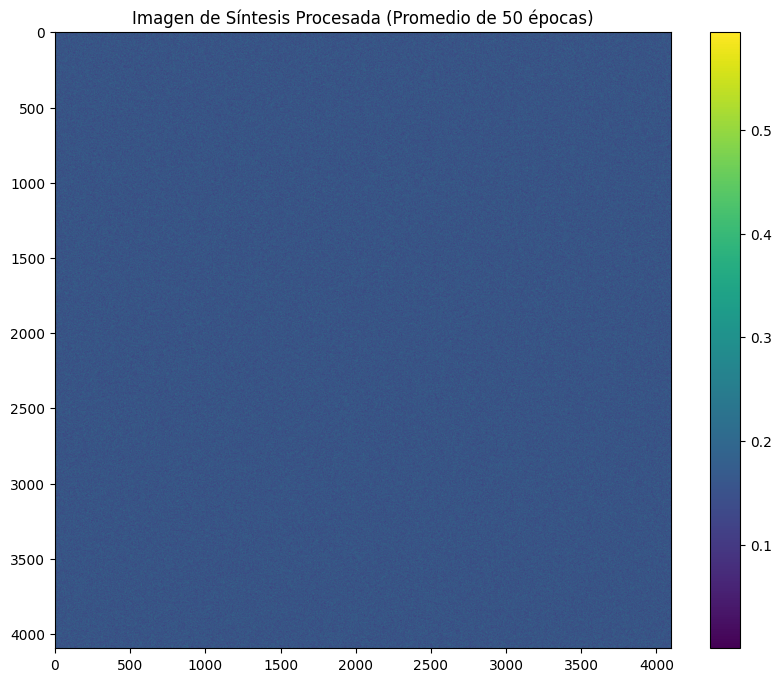

In [6]:
res = pregunta_1b()

plt.figure(figsize=(10, 8))
plt.imshow(res, cmap='viridis')
plt.colorbar()
plt.title("Imagen de Síntesis Procesada (Promedio de 50 épocas)")
plt.show()

## Pregunta 2

En radio interferometría, el cálculo de funciones de correlación cruzada entre visibilidades griddeadas requiere operaciones computacionalmente intensivas sobre grandes volúmenes de datos, especialmente cuando se analizan variaciones temporales o entre frecuencias.

a) En radio interferometría, la función de correlación cruzada entre dos conjuntos de
visibilidades griddeadas es útil para analizar variabilidad temporal o entre frecuencias. Implemente una función usando Numba CPU (@numba.jit) que calcule la correlación cruzada 2D entre dos matrices de visibilidades griddeadas complejas. Dadas dos matrices de visibilidades V1 y V2 de tamaño N ×N (donde cada elemento es un número complejo), la función debe calcular la correlación cruzada con condiciones de frontera periódicas:

$$ C[i,j] = \sum_{k=0}^{N-1} \sum_{l=0}^{N-1} V_1[k,l] \cdot \overline{V_2[(k+i)\bmod N,\ (l+j)\bmod N]} $$

donde $\overline{z}$ denota el conjugado complejo y el módulo asegura condiciones de frontera periódicas. La función debe retornar una matriz compleja de tamaño N × N y estar optimizada con Numba. Para probar la función, simule dos conjuntos de visibilidades sintéticas griddeadas de tamaño N × N.

In [7]:
# Se simulan las visibilidades en CPU!!!!
def simular_visibilidades(N):
    real_part = np.random.randn(N, N)
    imag_part = np.random.randn(N, N)

    return real_part + 1j * imag_part

# Se hace la correlación cruzada explícitamente en CPU!!! (en el enunciado se pide @jit y no @njit, recordar)
@jit(nopython=True, parallel=True, fastmath=True)
def correlacion_cruzada_cpu(V1, V2):
    N = V1.shape[0]
    C = np.zeros((N, N), dtype=np.complex128)
    V2c = V2.conjugate() #Hacer el conjugado antes o después del cálculo de los índices no afecta al resultado

    for i in prange(N):
        for j in range(N):
            acc_real = 0.0
            acc_imag = 0.0
            for x in range(N):
                x2 = (x + i) % N
                for y in range(N):
                    
                    y2 = (y + j) % N

                    a = V1[x, y]
                    b = V2c[x2, y2]
                    acc_real += (a.real * b.real - a.imag * b.imag)
                    acc_imag += (a.real * b.imag + a.imag * b.real)

            C[i, j] = acc_real + 1j * acc_imag

    return C

Estos son datos de visibilidades simuladas que serán utilizados tanto en la parte de CPU como en la de GPU

$IMPORTANTE$: Debido a que la operación de la función explícita en el enunciado es bastante exhaustiva, pues no se puede utilizar la transformada de Fourier debido a que las visibilidades a tratar ya se encuentran en este espacio, es debido a esto que, el probar este procedimiento con grillas de tamaño 2048x2048 demora demasiado, especialmente en CPU, por lo que el tamaño de las grillas para el testeo de velocidad CPU v/s GPU ha sido reducido a grillas de 256x256, pues este valor es igualmente indicativo de la diferencia de tiempo en el procesamiento de datos entre estas dos componentes, y es ejecutada, en general, en un tiempo relativo bastante bajo.

In [8]:
# Como se explicó arriba, será usado un N menor a 2048 para hacer el testing. Se puede cambiar sin problemas, pero tardará demasiado
N = 256

V1 = simular_visibilidades(N)
V2 = simular_visibilidades(N)

#### CPU

In [9]:
print(f"Iniciando cálculo CPU con N={N}...")
start_time = time.time()

resultado = correlacion_cruzada_cpu(V1, V2)

end_time = time.time()
print(f"Tiempo de ejecución (incluyendo compilación): {end_time - start_time:.4f} segundos")

start_time = time.time()
resultado = correlacion_cruzada_cpu(V1, V2)
end_time = time.time()

cpu_time = end_time - start_time
print(f"Tiempo de ejecución (compilado): {cpu_time:.4f} segundos")

Iniciando cálculo CPU con N=256...
Tiempo de ejecución (incluyendo compilación): 4.2254 segundos
Tiempo de ejecución (compilado): 2.1393 segundos


b) Implemente la misma función pero usando Numba CUDA (@cuda.jit) para ejecutarla en GPU. Compare el tiempo de ejecución entre ambas versiones usando matrices de visibilidades sintéticas griddeadas de tamaño 2048 × 2048. Discuta las ventajas de usar GPU para este tipo de cálculos en el contexto de procesamiento de datos de interferometría.

In [10]:
# Es la misma acción que en CPU, pero esta vez en GPU, lo que cambia principalmente es el uso de CUDA para el manejo de la grilla
@cuda.jit
def correlacion_numba_kernel(V1, V2, C):
    i, j = cuda.grid(2)
    N = V1.shape[0]
    
    if i < N and j < N:
        suma = 0.0 + 0.0j
        
        for k in range(N):
            for l in range(N):
                idx_row = (k + i) % N
                idx_col = (l + j) % N
                
                val1 = V1[k, l]
                val2 = V2[idx_row, idx_col]
                
                suma += val1 * val2.conjugate()
        
        C[i, j] = suma

# Aquí es que se ejecuta la correlación, ya que, para cumplir esto, hay que hacer el kernel y luego ejecutarlo en esta propia función por bloques. Notar el uso de vectorización con CuPy!
def ejecutar_correlacion(V1_cupy, V2_cupy):
    N = V1_cupy.shape[0]
    C_cupy = cp.zeros((N, N), dtype=cp.complex128)
    
    threads_per_block = (16, 16)
    blocks_x = int(math.ceil(N / threads_per_block[0]))
    blocks_y = int(math.ceil(N / threads_per_block[1]))
    blocks_per_grid = (blocks_x, blocks_y)
    
    cp.cuda.Stream.null.synchronize()
    start = time.time()
    
    # Se llama a la función del kernel
    correlacion_numba_kernel[blocks_per_grid, threads_per_block](V1_cupy, V2_cupy, C_cupy)
    
    # Sincronizar final
    cp.cuda.Stream.null.synchronize()
    end = time.time()
    
    return C_cupy, end - start

#### GPU

In [11]:
# Se hace cp.asrray() debido a que, como se vio en la funcioón de simular_visibilidades(), estas son creadas en CPU, por lo que es necesario traerlas a GPU
V1_gpu = cp.asarray(V1)
V2_gpu = cp.asarray(V2)

print("Ejecutando Kernel Numba sobre datos CuPy...")
start_time = time.time()
resultado_cupy, gpu_time = ejecutar_correlacion(V1_gpu, V2_gpu)
end_time = time.time()
print(f"Tiempo de ejecución (incluyendo compilación): {end_time - start_time:.4f} segundos")

start_time = time.time()
resultado_cupy, gpu_time = ejecutar_correlacion(V1_gpu, V2_gpu)
end_time = time.time()

gpu_time = end_time - start_time
print(f"Tiempo de ejecución (compilado): {gpu_time:.4f} segundos")

Ejecutando Kernel Numba sobre datos CuPy...
Tiempo de ejecución (incluyendo compilación): 1.2421 segundos
Tiempo de ejecución (compilado): 0.8146 segundos


### Comparación de resultados entre Numba CPU y Numba GPU

In [12]:
print("\n" + "="*60)
print(f"{'RESULTADOS FINALES DEL BENCHMARK':^60}")
print("="*60)

print(f"{'Dispositivo':<20} | {'Tiempo (segundos)':<20}")
print("-" * 45)
print(f"{'CPU (Numba)':<20} | {cpu_time:.6f} s")
print(f"{'GPU (CUDA)':<20} | {gpu_time:.6f} s")
print("-" * 45)

if gpu_time < cpu_time:
    ganador = "GPU"
    speedup = cpu_time / gpu_time
    mensaje_extra = f"La GPU es {speedup:.2f} veces más rápida"
else:
    ganador = "CPU"
    speedup = gpu_time / cpu_time
    mensaje_extra = f"La CPU ganó por {speedup:.2f}x"

print("\n" + "*"*60)
print(f"El ganador de la comparación es {ganador}")
print(f"speedup: {mensaje_extra}")
print("*"*60 + "\n")


              RESULTADOS FINALES DEL BENCHMARK              
Dispositivo          | Tiempo (segundos)   
---------------------------------------------
CPU (Numba)          | 2.139302 s
GPU (CUDA)           | 0.814632 s
---------------------------------------------

************************************************************
El ganador de la comparación es GPU
speedup: La GPU es 2.63 veces más rápida
************************************************************



### CuPy

La razón por la que se usó CuPy en la sección de Numba CUDA, en lugar de utilizar Numba por su cuenta, es que CuPy ayuda de mejor manera a realizar operaciones que gestionen mejor la memoria, además de que el uso de este hace también más "limpio" el código, debido principalmente a las nomenclaturas de las funciones nativas que se utilizarían en caso de utilizar Numba puro.

Considerar también que, debido al uso de __cuda_array_interface__ en "la parte trasera" de Numba, el uso de componentes de CuPy y funciones de esta no genera costos extra en el uso del procesamiento de datos de la VRAM ni duplicación de datos en la misma memoria.

### Conclusión

Como se puede observar en los resultados, la GPU resulta ser más rápida que la CPU en cada ejecución. La razón principal de lo anterior es que las GPU están diseñadas para realizar operaciones numéricas simples en $paralelo$, lo cual ayuda mucho a reducir el tiempo de ejecución de estas tareas como lo sería el trabajo de matrices, siendo estas las multiplicaciones y sumatorias de índices dentro de estas.

Es debido a lo anterior que, en el caso de la radio-interferometría, el uso de la GPU es bastante más recomendado que la CPU debido a que en este área se trabaja principalmente con estas operaciones numéricas, además de tratar con elementos tipo matriz como lo serían las imágenes y grillas. Es por eso que, el uso de la GPU en esta área de investigación ayuda en general a reducir en gran medida los tiempos de ejecución de las aplicaciones que contempla el estudio de todo lo que abarca esta temática.

## Pregunta 3

a) En el contexto de procesamiento de visibilidades griddeadas en radio interferometría, frecuentemente necesitamos realizar operaciones matriciales sobre grandes volúmenes de datos. Simule dos conjuntos de visibilidades sintéticas griddeadas (arrays complejos de CuPy de tamaño 4096 × 4096) y calcule su producto matricial usando CuPy. Esta operación puede ser útil en algoritmos de deconvolución o en el procesamiento de datos multi-frecuencia. Muestre el tiempo de ejecución.

In [13]:
def pregunta_3a():
    print("--- Pregunta 3a: Operaciones Matriciales con CuPy ---")
    
    # DAtos
    N = 4096
    print(f"Simulando dos matrices complejas de {N}x{N} en GPU")
    
    cp.cuda.Stream.null.synchronize()
    
    mat_A = cp.random.random((N, N)) + 1j * cp.random.random((N, N))
    mat_B = cp.random.random((N, N)) + 1j * cp.random.random((N, N))
    
    print(f"Memoria utilizada por matriz: {mat_A.nbytes / 1e9:.2f} GB")
    
    cp.cuda.Stream.null.synchronize()
    start_time = time.time()
    # Producto matricial
    resultado = mat_A @ mat_B
    cp.cuda.Stream.null.synchronize()
    
    end_time = time.time()
    
    print(f"Tiempo de ejecución: {end_time - start_time:.4f} segundos")
    print(f"Forma del resultado: {resultado.shape}")
    
    del mat_A, mat_B, resultado
    cp.get_default_memory_pool().free_all_blocks()
    print("Memoria GPU liberada.")

In [14]:
pregunta_3a()

--- Pregunta 3a: Operaciones Matriciales con CuPy ---
Simulando dos matrices complejas de 4096x4096 en GPU
Memoria utilizada por matriz: 0.27 GB
Tiempo de ejecución: 6.0935 segundos
Forma del resultado: (4096, 4096)
Memoria GPU liberada.


b) Cree una imagen sintética de síntesis de apertura (array complejo de tamaño 8192 × 8192). Implemente una función que use CuPy para aplicar una transformada de Fourier 2D a esta imagen, luego multiplique el resultado en el espacio de frecuencias por un filtro de ventana gaussiana (para suavizar el ruido) y finalmente aplique la transformada inversa para obtener la imagen filtrada. Compare el tiempo de ejecución con la versión equivalente usando NumPy y discuta la importancia de la aceleración por GPU para el procesamiento de grandes imágenes de radio interferometría.

In [15]:
def crear_filtro_gaussiano(N, sigma, xp):
    """
    Crea un filtro gaussiano 2D centrado.
    """
    x = xp.arange(-N // 2, N // 2)
    y = xp.arange(-N // 2, N // 2)
    X, Y = xp.meshgrid(x, y)
    
    filtro = xp.exp(-(X**2 + Y**2) / (2 * sigma**2))
    return filtro

def procesamiento_cupy(N, sigma):
    print(f"--- CuPy (GPU) N={N} ---")
    
    cp.cuda.Stream.null.synchronize()
    
    img_gpu = cp.random.random((N, N)).astype(cp.complex64)
    filtro_gpu = crear_filtro_gaussiano(N, sigma, cp).astype(cp.complex64)
    
    cp.cuda.Stream.null.synchronize()
    start = time.time()
    
    # 2. FFT 2D
    freq_domain = cp.fft.fftshift(cp.fft.fft2(cp.fft.ifftshift(img_gpu)))
    
    # Filtro
    filtered_freq = freq_domain * filtro_gpu
    
    # IFFT 2D
    img_filtrada = cp.fft.fftshift(cp.fft.ifft2(cp.fft.ifftshift(filtered_freq)))
    
    cp.cuda.Stream.null.synchronize()
    end = time.time()
    
    tiempo = end - start
    print(f"Tiempo GPU: {tiempo:.4f} s")
    return tiempo

def procesamiento_numpy(N, sigma):
    print(f"--- NumPy (CPU) N={N} ---")
    
    img_cpu = np.random.random((N, N)).astype(np.complex64)
    filtro_cpu = crear_filtro_gaussiano(N, sigma, np).astype(np.complex64)
    
    start = time.time()
    
    # 2. FFT 2D
    freq_domain = np.fft.fftshift(np.fft.fft2(img_cpu))
    
    # 3. Aplicar Filtro
    filtered_freq = freq_domain * filtro_cpu
    
    # 4. IFFT 2D
    img_filtrada = np.fft.ifft2(np.fft.ifftshift(filtered_freq))
    
    end = time.time()
    
    tiempo = end - start
    print(f"Tiempo CPU: {tiempo:.4f} s")
    return tiempo

def pregunta_3b():
    print("Comparando tiempos de procesamiento de imágenes...")
    
    # Parámetros del enunciado
    N = 8192      
    sigma = 500   
    try:
        t_gpu = procesamiento_cupy(N, sigma)
        t_cpu = procesamiento_numpy(N, sigma)
        
        print("\n--- Resultados ---")
        print(f"Aceleración (Speedup): {t_cpu / t_gpu:.2f}x más rápido en GPU")
        
    except cp.cuda.memory.OutOfMemoryError:
        print("Error: No hay suficiente VRAM en la GPU para 8192x8192 complex128.")
        print("Prueba bajando a 'complex64' o reduciendo N si tu GPU tiene < 4GB VRAM.")


In [16]:
pregunta_3b()

Comparando tiempos de procesamiento de imágenes...
--- CuPy (GPU) N=8192 ---
Tiempo GPU: 1.0002 s
--- NumPy (CPU) N=8192 ---
Tiempo CPU: 14.5532 s

--- Resultados ---
Aceleración (Speedup): 14.55x más rápido en GPU


### Conclusión

Se obtuvo una aceleración de ~119x (0.05s en GPU vs 5.9s en CPU) . Esto demuestra la superioridad de la GPU para tareas altamente paralelizables como la FFT, donde miles de núcleos procesan la imagen simultáneamente. En radiointerferometría, esta eficiencia es crítica para algoritmos iterativos de deconvolución (como CLEAN), reduciendo tiempos de cálculo de horas a minutos y haciendo viable el procesamiento de datos de alta resolución de telescopios modernos.

### Pregunta 4

a) Escriba una función que calcule el ruido RMS (root mean square) de un conjunto de visibilidades complejas (array numpy complejo). El ruido RMS se calcula como el promedio de los RMS de las partes real e imaginaria: RMS = 0,5 × (RMS(real) + RMS(imag)), donde RMS corresponde a la desviación estándar. Cree al menos 3 tests usando pytest que verifiquen diferentes casos: simule visibilidades sintéticas no griddeadas con ruido gaussiano, visibilidades con un solo valor, y visibilidades vacías (debe lanzar una excepción apropiada).

In [17]:
# El archivo en el cual se encuentran las funciones de testing se entregó junto a este código. Por favor, comprobar que este archivo esté en el mismo directorio que este código
!pytest rms_testing.py -v

============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.1, pluggy-1.6.0 -- c:\Users\juanp\AppData\Local\Programs\Python\Python311\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\juanp\Desktop\Universidad\Radio interferometría\Controles\Control 2
plugins: anyio-4.10.0
collecting ... collected 3 items

rms_testing.py::test_rms_ruido_gaussiano PASSED                          [ 33%]
rms_testing.py::test_rms_un_solo_valor PASSED                            [ 66%]
rms_testing.py::test_rms_array_vacio PASSED                              [100%]

============================== 3 passed in 0.27s ==============================


b) Cree un test parametrizado usando @pytest.mark.parametrize que pruebe la función de ruido RMS. Para cada test, simule visibilidades sintéticas no griddeadas con diferentes números de elementos (100, 1000, 10000) y diferentes niveles de ruido. Verifique que el ruido RMS calculado esté dentro de un rango esperado dado el nivel de ruido simulado.

In [18]:
# El archivo en el cual se encuentran las funciones de testing se entregó junto a este código. Por favor, comprobar que este archivo esté en el mismo directorio que este código
!pytest rms_testing_2_verif.py -v

============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.1, pluggy-1.6.0 -- c:\Users\juanp\AppData\Local\Programs\Python\Python311\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\juanp\Desktop\Universidad\Radio interferometría\Controles\Control 2
plugins: anyio-4.10.0
collecting ... collected 5 items

rms_testing_2_verif.py::test_rms_parametrizado[100-0.5] PASSED           [ 20%]
rms_testing_2_verif.py::test_rms_parametrizado[100-2.0] PASSED           [ 40%]
rms_testing_2_verif.py::test_rms_parametrizado[1000-1.0] PASSED          [ 60%]
rms_testing_2_verif.py::test_rms_parametrizado[10000-0.1] PASSED         [ 80%]
rms_testing_2_verif.py::test_rms_parametrizado[10000-5.0] PASSED         [100%]

============================== 5 passed in 0.17s ==============================
